# Week 7 - Advanced Models

**Question:** Can gradient boosting improve California single-family-home price prediction over the Week 6 Random Forest benchmark?

**Answer:** Yes. XGBoost produced the highest May validation R2 and the lowest dollar error, so it was locked before the June test.

## 1. Plan

1. Reuse the cleaned data and feature logic from previous weeks.
2. Tune XGBoost, LightGBM, and CatBoost using May only.
3. Compare them with Random Forest and lock one model.
4. Evaluate the locked model once on June.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "week7" else Path.cwd()
sys.path.insert(0, str(ROOT / "week7"))

from week7_modeling import (
    evaluate, load_june, load_train_validation, june_comparison,
    tune_boosting_models, validation_comparison,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 2. Reuse the Existing Data Pipeline

In [2]:
data = load_train_validation(ROOT)

print(f"Training (Feb 2025-Apr 2026): {data['train_rows']:,} rows")
print(f"Validation (May 2026): {data['validation_rows']:,} rows")
print("Final test: June 2026")
print(f"Model features: {data['x_train'].shape[1]}")

Training (Feb 2025-Apr 2026): 151,691 rows
Validation (May 2026): 11,753 rows
Final test: June 2026
Model features: 38


- Numeric features use train-fitted median imputation and scaling.
- Categories use train-only **frequency encoding**.
- Missing-value flags are not used as model features.

## 3. Tune Three Boosting Models

A light search tests:

| Setting | Values |
|---|---|
| Tree depth | 3, 4, 6 |
| Learning rate | 0.03, 0.05 |
| Maximum trees | 1,500 with early stopping |
| Regularization | row sampling, feature sampling, child size, L1/L2 |

May 2026 selects the best settings. June is not used here.

In [3]:
search_results, best_results, boosting_models = tune_boosting_models(data)
print(f"Completed {len(search_results)} configurations.")

Completed 24 configurations.


In [4]:
tuning_summary = best_results.assign(
    May_R2=best_results["validation_R2"],
    May_MAPE=best_results["validation_MAPE"] * 100,
    May_MdAPE=best_results["validation_MdAPE"] * 100,
)[["model", "depth", "learning_rate", "trees", "May_R2", "May_MAPE", "May_MdAPE"]]

tuning_summary.round({"May_R2": 3, "May_MAPE": 2, "May_MdAPE": 2})

,model,depth,learning_rate,trees,May_R2,May_MAPE,May_MdAPE
0,CatBoost,6,0.05,1500,0.903,12.54,8.74
1,LightGBM,6,0.05,1500,0.904,12.38,8.60
2,XGBoost,6,0.05,1495,0.908,12.18,8.38


**Tuning result:** XGBoost achieved the strongest validation performance. All three models selected depth `6` and learning rate `0.05`.

## 4. Select the Final Model

In [5]:
comparison, random_forest = validation_comparison(data, best_results, boosting_models)
comparison_table = comparison.rename(columns={
    "MAPE": "MAPE (%)",
    "MdAPE": "MdAPE (%)",
    "Gap": "MdAPE gap (pp)",
})
comparison_table.sort_values("R2", ascending=False).round({
    "R2": 3, "MAE": 0, "MAPE (%)": 2,
    "MdAPE (%)": 2, "MdAPE gap (pp)": 2,
})

,Model,R2,MAE,MAPE (%),MdAPE (%),MdAPE gap (pp)
0,XGBoost,0.908,155112.0,12.18,8.38,0.79
1,LightGBM,0.904,158205.0,12.38,8.60,0.73
2,CatBoost,0.903,159446.0,12.54,8.74,0.65
3,Random Forest,0.889,160504.0,12.01,7.73,2.90


- **Lock XGBoost:** highest May R2 (`0.908`) and lowest May dollar error.
- **Tradeoff:** Random Forest's MdAPE is `0.65` percentage points lower.
- **Overfitting:** the MdAPE gap is May error minus training error; XGBoost's smaller gap indicates better stability.

## 5. Locked XGBoost

| Hyperparameter | Final value |
|---|---:|
| Maximum depth | 6 |
| Learning rate | 0.05 |
| Trees selected by early stopping | 1,495 |
| Row sampling | 0.85 |
| Feature sampling | 0.85 |
| L1 / L2 | 0 / 1 |

These settings were locked before opening the June test results.

## 6. Final June Test

In [6]:
june = load_june(ROOT, data["state"], data["bounds"])
june_results, june_predictions = june_comparison(
    june,
    {"XGBoost": boosting_models["XGBoost"], "Random Forest": random_forest},
)

june_results.sort_values("R2", ascending=False).round(
    {"R2": 3, "MAE": 0, "RMSE": 0, "MAPE": 2, "MdAPE": 2}
)

,Model,R2,MAE,RMSE,MAPE,MdAPE
0,XGBoost,0.911,154492.0,284502.0,12.17,8.46
1,Random Forest,0.891,160592.0,314448.0,12.01,7.80


- **XGBoost June result:** R2 `0.911`, MAPE `12.17%`, MdAPE `8.46%`.
- **Improvement:** XGBoost has higher R2 and lower MAE/RMSE than Random Forest.
- **Meaning:** use XGBoost for pricing review and valuation triage, not automatic final pricing.

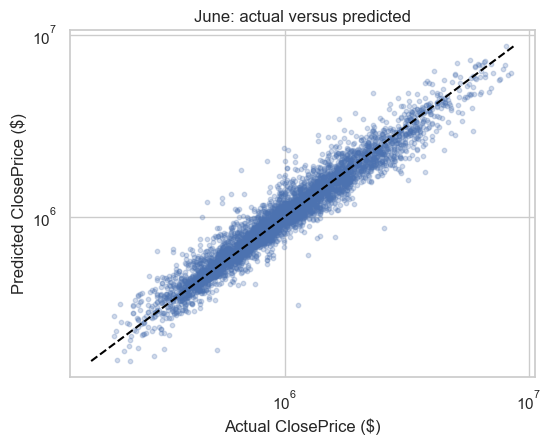

In [7]:
mask = june["primary_mask"]
plot_data = pd.DataFrame({
    "Actual": june["y"][mask],
    "Predicted": june_predictions["XGBoost"][mask],
}).sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(plot_data["Actual"], plot_data["Predicted"], s=10, alpha=0.25)
low, high = plot_data.min().min(), plot_data.max().max()
ax.plot([low, high], [low, high], "--", color="black")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual ClosePrice ($)")
ax.set_ylabel("Predicted ClosePrice ($)")
ax.set_title("June: actual versus predicted")
plt.show()

**Interpretation:** predictions generally follow actual prices, while unusual and high-value properties remain harder to estimate.

## 7. Feature Importance

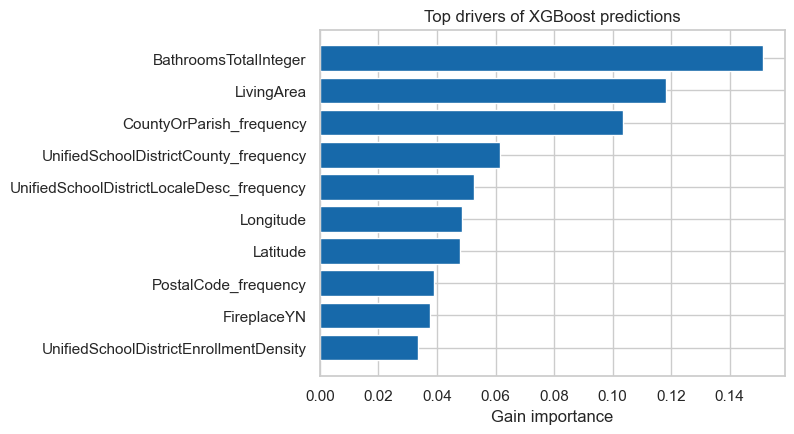

In [8]:
importance = pd.DataFrame({
    "Feature": data["x_train"].columns,
    "Importance": boosting_models["XGBoost"].feature_importances_,
}).nlargest(10, "Importance").sort_values("Importance")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh(importance["Feature"], importance["Importance"], color="#1769AA")
ax.set_xlabel("Gain importance")
ax.set_ylabel("")
ax.set_title("Top drivers of XGBoost predictions")
plt.show()

- **Property characteristics:** living area and bathrooms provide strong property-level signals.
- **Location:** county, ZIP, and school-district frequency capture geographic market differences.
- **Interpretation:** importance measures predictive contribution, not causality.

## 8. Robustness

In [9]:
full_june = evaluate(june["y"], june_predictions["XGBoost"])
pd.DataFrame([{
    "R2": full_june["R2"],
    "MAPE (%)": full_june["MAPE"] * 100,
    "MdAPE (%)": full_june["MdAPE"] * 100,
}], index=["All June transactions"]).round(3)

,R2,MAPE (%),MdAPE (%)
All June transactions,0.678,13.814,8.665


- The main results focus on typical market transactions using limits learned from training data only.
- When all June transactions are included, performance falls because luxury and unusual properties are harder to predict.
- These properties should receive manual review rather than automatic pricing recommendations.

## 9. Conclusion

- **Final model:** XGBoost.
- **Main pricing signals:** living area, bathrooms, geography, ZIP, and school-district frequency.
- **Limitation:** one validation month and one test month; feature importance is predictive, not causal.
- **Business use:** flag potentially mispriced listings and support agent pricing review.